# CIFAR-10 分类 —— InceptionNet 多分支卷积网络（卷积神经网络CNN2.md）

本脚本实现了 CIFAR-10 数据集的 10 分类任务，整合了以下内容：
1. Kaggle 数据准备（PNG 图片 + CSV 标签）
2. 自定义 CIFAR10WithCSV Dataset 类（根据 CSV 标签读取 PNG 图片）
3. 数据预处理与增强（RandomHorizontalFlip、RandomCrop、Normalize）
4. Trainer 通用训练器类（含早停、TensorBoard、绘图、回归支持）
5. InceptionBlock —— 多分支并行卷积块（1×1, 3×3, 5×5, maxpool 四分支）
6. InceptionNetCIFAR10 —— 面向 CIFAR-10 的 Inception 风格模型
7. torchviz 模型计算图可视化（可直观看到多分支结构）
8. 参数统计与前向传播验证
9. 模型总结与分析

## 0. 导入所有需要的库

In [7]:
import torch  # PyTorch 核心库，提供张量运算与自动求导
import torch.nn as nn  # 神经网络模块，提供 Conv2d、Linear、ReLU、BatchNorm2d 等层
import torch.optim as optim  # 优化器模块，提供 SGD、Adam 等
from torch.utils.data import Dataset, DataLoader  # Dataset: 自定义数据集基类；DataLoader: 批量加载器
from torchvision import transforms  # 数据预处理模块，提供 Compose、ToTensor、Normalize 等
import matplotlib.pyplot as plt  # 绘图库，用于训练曲线可视化
import os  # 操作系统接口，用于路径拼接、文件存在检查、目录创建
import pandas as pd  # 数据处理库，用于读取 CSV 标签文件
from PIL import Image  # 图像处理库，用于加载 PNG/JPG 图片
from torch.utils.tensorboard import SummaryWriter  # TensorBoard 写入器，用于记录训练日志
from torchviz import make_dot  # torchviz 用于绘制模型计算图，可视化前向传播路径（包括多分支结构）

## 1. 数据准备 —— 路径与标签 CSV

In [8]:
# 图像主目录（训练集 PNG 图片存放位置）
data_dir = './data/cifar-10/train/train'  # 本地路径：训练图片文件夹，内含 50000 张 PNG
# 标签 CSV 文件路径
label_csv = './data/cifar-10/trainLabels.csv'  # 本地路径：标签 CSV，包含 id 和 label 两列

## 2. 数据预处理变换定义

### 训练集 transform：数据增强 + 归一化
transforms.Compose 将多个变换操作按顺序组合，依次执行

In [9]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),  # 随机水平翻转：以 50% 概率将图片左右翻转，增加数据多样性
    transforms.RandomCrop(32, padding=4),  # 随机裁剪：先在四周各补 4 像素（填充 0），再随机裁剪回 32×32
    transforms.ToTensor(),  # 将 PIL.Image (0-255 整数) 转为 torch.Tensor (0.0-1.0 浮点)，维度 H×W×C → C×H×W
    transforms.Normalize((0.4915, 0.4821, 0.4464), (0.2472, 0.2437, 0.2617))  # 用 CIFAR-10 训练集的通道均值和标准差做标准化
])

### 验证集/测试集 transform：仅基础预处理，不做数据增强

In [10]:
val_transform = transforms.Compose([
    transforms.ToTensor(),  # PIL.Image → Tensor，值域 0~1，维度 HWC → CHW
    transforms.Normalize((0.4915, 0.4821, 0.4464), (0.2472, 0.2437, 0.2617))  # 使用与训练集相同的标准化参数（均值, 标准差）
])

## 3. 自定义 Dataset 类 —— CIFAR10WithCSV
CIFAR-10 图片按 id.png 命名（如 1.png, 2.png, ...），标签在 trainLabels.csv 中（列: id, label）
该类继承 torch.utils.data.Dataset，必须实现 __len__ 和 __getitem__ 两个方法
CSV 格式示例:
  id,label
  1,frog
  2,truck
  3,automobile
  ...

In [11]:
class CIFAR10WithCSV(Dataset):
    """
    根据 DataFrame 子集读取 CIFAR-10 图片与标签的自定义数据集类

    CIFAR-10 目录结构：
      data_dir/
        1.png      (id=1 的图片，标签在 CSV 中)
        2.png
        ...
        50000.png

    该类的作用: 将分散的 PNG 文件和标签 CSV 文件组织成 PyTorch Dataset，供 DataLoader 使用
    """

    def __init__(self, img_dir, labels_frame, class_to_idx, transform=None):
        """
        初始化 CIFAR-10 数据集

        参数:
            img_dir:       图片文件夹路径，内含 PNG 文件（以数字 id 命名）
            labels_frame:  pandas DataFrame，包含图片 id 和 label 两列
            class_to_idx:  dict，类别名称→整数索引的映射，如 {'airplane':0, 'automobile':1, ...}
            transform:     数据预处理变换（Compose 对象），默认为 None
        """
        self.img_dir = img_dir  # 保存图片目录路径
        self.labels_frame = labels_frame  # 保存标签 DataFrame（含 id 列和 label 列）
        self.class_to_idx = class_to_idx  # 保存类别→索引映射字典
        self.transform = transform  # 保存数据预处理变换（训练用增强，验证仅归一化）

    def __len__(self):
        """返回数据集总样本数"""
        return len(self.labels_frame)  # 样本数 = DataFrame 的行数（即图片张数）

    def __getitem__(self, idx):
        """
        根据索引获取单个样本（图片 + 标签）

        参数:
            idx: 样本索引（0 ~ len-1）
        返回:
            (image, label): image 是预处理后的 Tensor (3,32,32)，label 是 0~9 的整数索引
        """
        img_number = str(self.labels_frame.iloc[idx, 0])  # 获取第 idx 行、第 0 列的图片 id（转为字符串用于拼接路径）
        img_name = os.path.join(self.img_dir, img_number + '.png')  # 拼接完整图片路径: data_dir/id.png
        image = Image.open(img_name).convert('RGB')  # 用 PIL 打开图片并确保为 RGB 三通道模式（丢弃 alpha 通道）
        label_name = self.labels_frame.iloc[idx, 1]  # 获取第 idx 行、第 1 列的类别名称（如 'frog'、'cat' 等）
        label = self.class_to_idx[label_name]  # 将类别名称映射为整数索引 0~9
        if self.transform:  # 如果传入了预处理变换
            image = self.transform(image)  # 对图片应用变换（ToTensor → Normalize 等）
        return image, label  # 返回 (图像Tensor, 标签整数)

## 4. 数据加载与划分

### 读取标签 CSV 文件

In [12]:
labels_df = pd.read_csv(label_csv)  # 用 pandas 读取训练标签文件（50000 行 × 2 列: id, label）
print("标签 CSV 总行数:", len(labels_df))  # 应输出 50000

标签 CSV 总行数: 50000


### 划分训练集与验证集

In [13]:
train_size = 45000  # 训练集样本数: 前 45000 张（90%）
val_size = 5000  # 验证集样本数: 后 5000 张（10%）
assert train_size + val_size <= len(labels_df), "数据集图片数量不足！"  # 断言确保数据量足够划分

In [14]:
# iloc 按位置索引切片:
#   [:train_size]       → 前 45000 行作为训练集标签
#   [train_size:train_size+val_size] → 第 45001~50000 行作为验证集标签
# reset_index(drop=True): 重置行索引为 0,1,2,...，丢弃旧索引
train_labels_df = labels_df.iloc[:train_size].reset_index(drop=True)  # 训练集标签 DataFrame，重置行索引
val_labels_df = labels_df.iloc[train_size:train_size + val_size].reset_index(drop=True)  # 验证集标签 DataFrame，重置行索引

### 建立类别映射
sorted 保证类别按字母序排列，使训练/验证/测试集的类别编号完全一致

In [15]:
class_names = sorted(labels_df['label'].unique())  # 获取所有不重复的类别名称（如 'airplane', 'automobile', ...），排序
class_to_idx = {cls: idx for idx, cls in enumerate(class_names)}  # 构建类别名→索引字典: {'airplane':0, 'automobile':1, ..., 'truck':9}
print("类别映射:", class_to_idx)  # 打印类别→索引映射供检查

类别映射: {'airplane': 0, 'automobile': 1, 'bird': 2, 'cat': 3, 'deer': 4, 'dog': 5, 'frog': 6, 'horse': 7, 'ship': 8, 'truck': 9}


### 创建 Dataset 实例

In [16]:
train_dataset = CIFAR10WithCSV(data_dir, train_labels_df, class_to_idx, transform=train_transform)  # 训练集 Dataset（含数据增强）
val_dataset = CIFAR10WithCSV(data_dir, val_labels_df, class_to_idx, transform=val_transform)  # 验证集 Dataset（仅归一化，无增强）

### 创建 DataLoader
batch_size=128: 每批处理 128 张图片
shuffle=True: 训练集随机打乱，防止模型记忆样本顺序
pin_memory=True: 将 batch 数据放入 CUDA 固定内存区，GPU → GPU 传输时使用 DMA 更快
  若在 CPU 上运行会收到 pin_memory 警告，属正常现象，不影响运行

In [17]:
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, pin_memory=True)  # 训练集 DataLoader
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, pin_memory=True)  # 验证集 DataLoader: 不打乱，保持评估一致性

## 5. 数据集基本信息打印与验证

In [18]:
print("\n========== 数据集基本信息 ==========")  # 分隔标题
print("训练集样本数:", len(train_dataset))  # 45000
print("验证集样本数:", len(val_dataset))  # 5000
print("类别总数:", len(class_names))  # 10
print("类别名称:", class_names)  # ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


========== 数据集基本信息 ==========
训练集样本数: 45000
验证集样本数: 5000
类别总数: 10
类别名称: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


### 验证单个样本的形状和标签

In [19]:
sample_img, sample_label = train_dataset[0]  # 获取训练集第一个样本: (图像 Tensor, 标签)
print("单张图片 shape (C, H, W):", sample_img.shape)  # torch.Size([3, 32, 32]) —— 3 通道，32×32 像素
print("第一个样本的标签索引:", sample_label)  # 0~9 的整数（对应类别名称）

单张图片 shape (C, H, W): torch.Size([3, 32, 32])
第一个样本的标签索引: 6


### 验证一个 batch 的数据形状

In [20]:
for images, labels in train_loader:  # 取训练集第一个 batch
    print("一个 batch 的图片 shape:", images.shape)  # torch.Size([128, 3, 32, 32]) —— 128 张 3×32×32 图片
    print("一个 batch 的标签 shape:", labels.shape)  # torch.Size([128]) —— 128 个标签
    break  # 只取第一个 batch，立即跳出循环

一个 batch 的图片 shape: torch.Size([128, 3, 32, 32])
一个 batch 的标签 shape: torch.Size([128])


## 6. Trainer 通用训练器类
封装完整的训练流水线:
  训练循环 + 验证评估 + 早停 + 最优模型保存 + TensorBoard + 绘图
同时支持分类任务（记录准确率）与回归任务（仅记录损失）

In [21]:
class Trainer:
    """
    通用训练器：封装训练循环、评估、早停、模型保存与可视化

    支持两种任务:
      - 分类: 使用 train() + evaluating()，记录损失与准确率
      - 回归: 使用 regression_train() + regression_evaluating()，仅记录损失

    早停机制:
      - 监控验证集指标（损失或准确率），连续 patience 轮未提升则自动停止
      - 停止后自动恢复到训练过程中保存的最优模型权重
    """

    def __init__(
            self,
            model,  # 待训练的 PyTorch 模型实例（nn.Module）
            trainloader,  # 训练集 DataLoader
            valloader,  # 验证集 DataLoader
            criterion,  # 损失函数（如 CrossEntropyLoss、MSELoss）
            optimizer,  # 优化器（如 Adam、SGD）
            device='cuda',  # 训练设备: 'cuda'（GPU）或 'cpu'
            epochs=10,  # 最大训练轮数，默认 10 轮
            early_stopping=True,  # 是否启用早停机制，默认开启
            patience=5,  # 早停容忍度: 连续 patience 轮指标未提升则停止训练
            save_path="best_model.pth",  # 最优模型权重保存路径
            early_stop_mode="loss",  # 早停监控指标: "loss"（损失越小越好）或 "acc"（准确率）
            maximize_acc=True,  # early_stop_mode="acc" 时: True=准确率越大越好, False=越小越好
            use_tensorboard=False,  # 是否启用 TensorBoard 可视化日志
            log_dir='tensorboard_logs'  # TensorBoard 日志存放目录
    ):
        """初始化训练器，保存所有配置并创建 TensorBoard 写入器"""
        self.model = model  # 保存模型实例
        self.trainloader = trainloader  # 保存训练集加载器
        self.valloader = valloader  # 保存验证集加载器
        self.criterion = criterion  # 保存损失函数
        self.optimizer = optimizer  # 保存优化器
        self.device = device  # 保存训练设备（GPU/CPU）
        self.epochs = epochs  # 保存最大训练轮数

        # 训练历史记录列表（每个元素对应一个 epoch，用于最终绘图）
        self.train_losses = []  # 每轮训练集平均损失
        self.val_losses = []  # 每轮验证集平均损失
        self.train_accuracies = []  # 每轮训练集准确率（%）
        self.val_accuracies = []  # 每轮验证集准确率（%）

        # 早停相关配置
        self.early_stopping = early_stopping  # 是否启用早停
        self.patience = patience  # 早停容忍度（连续未提升多少轮就停）
        self.save_path = save_path  # 最优模型权重保存路径
        self.early_stop_mode = early_stop_mode  # 早停监控模式: "loss" 或 "acc"
        self.maximize_acc = maximize_acc  # acc 模式下: True=准确率越大越好, False=越小越好

        # 早停运行状态变量
        self.best_metric = None  # 历史最优度量值（初始为 None，第一个 epoch 自动记录）
        self.early_stop_counter = 0  # 连续未提升的轮数计数器
        self.best_epoch = 0  # 取得最优度量值时的 epoch 编号

        # TensorBoard 日志配置
        self.use_tensorboard = use_tensorboard  # 是否使用 TensorBoard
        self._writer = None  # TensorBoard SummaryWriter 句柄，初始为 None
        if self.use_tensorboard:  # 如果启用了 TensorBoard
            if not os.path.exists(log_dir):  # 检查日志目录是否存在
                os.makedirs(log_dir)  # 不存在则递归创建目录
            self._writer = SummaryWriter(log_dir)  # 创建 SummaryWriter 实例，绑定日志目录

    def evaluating(self, dataloader):
        """
        分类任务评估函数 —— 在给定数据上计算平均损失和准确率

        参数:
            dataloader: 待评估的数据加载器（验证集或测试集）
        返回:
            avg_loss: 平均损失（所有 batch 损失的平均）
            acc:      准确率（%，正确预测数 / 总样本数 × 100）
        """
        self.model.eval()  # 切换到评估模式: 关闭 Dropout、冻结 BatchNorm 运行统计量
        correct = 0  # 累计预测正确的样本数
        total = 0  # 累计总样本数
        running_loss = 0.0  # 累计总损失（用于求平均）

        with torch.no_grad():  # 禁用梯度计算，大幅节省显存和计算量（推理无需梯度）
            for images, labels in dataloader:  # 逐 batch 遍历
                images = images.to(self.device)  # 将当前 batch 图片数据移至 GPU/CPU
                labels = labels.to(self.device)  # 将当前 batch 标签数据移至 GPU/CPU
                outputs = self.model(images)  # 前向传播: 得到每类 logits，形状 (batch, 10)
                loss = self.criterion(outputs, labels)  # 计算当前 batch 的分类损失
                running_loss += loss.item()  # 累加损失（.item() 将 0 维 Tensor 转为 Python float）
                # torch.argmax(outputs, dim=1): 沿类别维度 (dim=1) 取最大值的索引作为预测类别
                predicted = torch.argmax(outputs, dim=1)  # 获取每个样本的预测类别 (0~9)
                total += labels.size(0)  # 累加当前 batch 的样本数（通常是 batch_size，最后一个 batch 可能更少）
                correct += (predicted == labels).sum().item()  # 累加预测正确的样本数（比较后求和再转 float）

        acc = 100 * correct / total if total > 0 else 0  # 准确率转为百分比（%），分母防零
        avg_loss = running_loss / len(dataloader)  # 平均损失 = 总损失 / batch 数量
        return avg_loss, acc  # 返回二元组 (平均损失, 准确率%)

    def regression_evaluating(self, dataloader):
        """
        回归任务评估函数 —— 只返回平均损失，不计算准确率

        参数:
            dataloader: 数据加载器
        返回:
            avg_loss: 平均损失
        """
        self.model.eval()  # 切换到评估模式
        running_loss = 0.0  # 累计损失初始化为 0
        with torch.no_grad():  # 禁用梯度计算
            for data, target in dataloader:  # 遍历每个 batch
                data = data.to(self.device)  # 输入数据移至设备
                target = target.to(self.device)  # 目标值移至设备
                output = self.model(data)  # 前向传播得到预测值
                loss = self.criterion(output, target)  # 计算损失（如 MSE）
                running_loss += loss.item()  # 累加损失
        avg_loss = running_loss / len(dataloader)  # 计算平均损失
        return avg_loss  # 返回平均损失（标量 float）

    def regression_train(self):
        """
        回归任务训练循环 —— 仅记录损失，不计算准确率

        与 train() 的区别: 评估时不计算准确率，只使用验证损失作为早停指标
        适用于房价预测、温度预测等连续值回归任务
        """
        self.model.to(self.device)  # 将模型参数迁移到目标设备
        for epoch in range(self.epochs):  # 逐轮训练，共 epochs 轮
            self.model.train()  # 切换到训练模式: 启用 Dropout、让 BatchNorm 更新统计量
            running_loss = 0.0  # 本轮损失累加器清零

            for batch_idx, (inputs, targets) in enumerate(self.trainloader):  # 遍历训练集每个 batch
                inputs = inputs.to(self.device)  # 输入数据移至设备
                targets = targets.to(self.device)  # 目标数据移至设备
                self.optimizer.zero_grad()  # 清空上一轮的梯度（PyTorch 默认累加梯度）
                outputs = self.model(inputs)  # 前向传播
                loss = self.criterion(outputs, targets)  # 计算损失
                loss.backward()  # 反向传播求梯度
                self.optimizer.step()  # 优化器更新参数: θ = θ - lr × ∇loss
                running_loss += loss.item()  # 累加损失值

                if (batch_idx + 1) % 100 == 0:  # 每 100 个 batch 打印一次当前进度
                    print(f"[Regression] Epoch [{epoch + 1}/{self.epochs}], "
                          f"Step [{batch_idx + 1}/{len(self.trainloader)}], Loss: {loss.item():.4f}")

            avg_train_loss = running_loss / len(self.trainloader)  # 本轮平均训练损失（batch 级）
            train_loss = self.regression_evaluating(self.trainloader)  # 在训练集上评估（得到更准确的损失）
            val_loss = self.regression_evaluating(self.valloader)  # 在验证集上评估
            self.train_losses.append(train_loss)  # 记录训练损失
            self.val_losses.append(val_loss)  # 记录验证损失
            print(f"[Regression] Epoch [{epoch + 1}/{self.epochs}], "
                  f"Loss: {avg_train_loss:.4f}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

            # ---- TensorBoard 日志记录 ----
            if self.use_tensorboard and self._writer is not None:
                self._writer.add_scalar('Train/Loss', train_loss, epoch + 1)  # 记录训练损失曲线
                self._writer.add_scalar('Val/Loss', val_loss, epoch + 1)  # 记录验证损失曲线
                for i, param_group in enumerate(self.optimizer.param_groups):  # 遍历所有参数组（通常是 1 组）
                    self._writer.add_scalar(f'LR/group_{i}', param_group['lr'], epoch + 1)  # 记录各组学习率

            # ---- 早停与模型保存 ----
            metric = val_loss  # 回归任务只用验证损失作为评估指标（越小越好）
            if self.early_stopping:  # 如果开启早停
                if self.best_metric is None or metric < self.best_metric:  # 首次记录（None）或当前损失更低 → 有提升
                    self.best_metric = metric  # 更新历史最优损失值
                    self.early_stop_counter = 0  # 重置早停计数器
                    self.best_epoch = epoch + 1  # 记录最优 epoch 编号（从 1 开始）
                    torch.save(self.model.state_dict(), self.save_path)  # 保存当前最优模型权重到文件
                    print(f"[Info][Regression] Model improved at epoch {epoch + 1}, saving to {self.save_path}")
                else:  # 损失未下降 → 无提升
                    self.early_stop_counter += 1  # 早停计数器 +1
                    print(f"[Info][Regression] Early stop counter: {self.early_stop_counter}/{self.patience}")
                    if self.early_stop_counter >= self.patience:  # 连续 patience 轮未提升
                        print(f"[Regression] Early stopping triggered at epoch {epoch + 1}. "
                              f"Best epoch: {self.best_epoch}, Best Loss: {self.best_metric:.4f}")
                        if os.path.isfile(self.save_path):  # 如果最优权重文件存在
                            self.model.load_state_dict(torch.load(self.save_path, map_location=self.device))  # 恢复最优权重
                        if self.use_tensorboard and self._writer is not None:
                            self._writer.close()  # 关闭 TensorBoard 写入器
                        return  # 提前结束训练

        # 全部 epoch 跑完且未触发早停: 加载训练过程中保存的最优权重
        if self.early_stopping and self.best_metric is not None:
            print(f"[Regression] Training finished. Loading best model from {self.save_path}")
            if os.path.isfile(self.save_path):  # 检查权重文件是否存在
                self.model.load_state_dict(torch.load(self.save_path, map_location=self.device))  # 恢复到最优状态
        if self.use_tensorboard and self._writer is not None:
            self._writer.close()  # 关闭 TensorBoard 写入器

    def _is_improvement(self, metric):
        """
        根据早停模式判断当前度量值是否优于历史最优

        参数:
            metric: 当前 epoch 的度量值（损失或准确率）
        返回:
            True = 有提升（优于历史最优）, False = 未提升
        """
        if self.best_metric is None:  # 尚无历史最优记录（第一个 epoch）
            return True  # 始终视为有提升（记作当前最优）
        if self.early_stop_mode == "loss":  # 损失模式: 损失越小越好
            return metric < self.best_metric  # 当前损失 < 历史最优损失 → 有提升
        elif self.early_stop_mode == "acc":  # 准确率模式
            if self.maximize_acc:  # 准确率越大越好（常规情况）
                return metric > self.best_metric  # 当前准确率 > 历史最优准确率 → 有提升
            else:  # 准确率越小越好（不常见，某些特殊指标）
                return metric < self.best_metric
        else:
            raise ValueError("Unknown early_stop_mode: {}".format(self.early_stop_mode))  # 未知模式抛出异常

    def _get_val_metric(self, val_loss, val_acc):
        """
        根据早停模式返回用于比较的度量值

        参数:
            val_loss: 当前验证集平均损失
            val_acc:  当前验证集准确率（%）
        返回:
            用于早停判断的度量值（损失值或准确率值）
        """
        if self.early_stop_mode == "loss":  # 以验证损失为早停依据
            return val_loss
        elif self.early_stop_mode == "acc":  # 以验证准确率为早停依据
            return val_acc
        else:
            raise ValueError("Unknown early_stop_mode: {}".format(self.early_stop_mode))

    def train(self):
        """
        分类任务训练主循环

        每个 epoch 的流程:
          1. 遍历训练集所有 batch，前向传播 → 计算损失 → 反向传播 → 更新参数
          2. 在训练集和验证集上分别评估损失与准确率
          3. 记录 TensorBoard 日志（如启用）
          4. 早停判断：若验证指标连续 patience 轮未提升则停止训练
          5. 每个 epoch 保存最优模型权重
        """
        self.model.to(self.device)  # 将模型参数迁移到目标设备 (GPU/CPU)

        for epoch in range(self.epochs):  # 逐轮训练，共 epochs 轮
            self.model.train()  # 切换到训练模式: 启用 Dropout、BatchNorm 统计量更新等
            running_loss = 0.0  # 当前 epoch 的损失累加器（batch 级别，用于实时显示）

            for batch_idx, (images, labels) in enumerate(self.trainloader):  # 遍历训练集每个 batch
                images = images.to(self.device)  # 将图片数据移到 GPU/CPU
                labels = labels.to(self.device)  # 将标签数据移到 GPU/CPU

                # ---- 核心训练五步（深度学习训练的标准范式） ----
                self.optimizer.zero_grad()  # 1. 清空上一轮累积的梯度（PyTorch 默认累加梯度，不手动清零会叠加）
                outputs = self.model(images)  # 2. 前向传播: 输入图片 → 模型 → 得到各类别 logits
                loss = self.criterion(outputs, labels)  # 3. 计算损失: logits 与真实标签之间的交叉熵
                loss.backward()  # 4. 反向传播: 根据损失自动计算所有 requires_grad=True 的参数的梯度
                self.optimizer.step()  # 5. 优化器更新参数: θ = θ - lr × ∇loss（对 Adam 会更复杂）

                running_loss += loss.item()  # 累加损失值（.item() 将标量张量提取为 Python float）

                if (batch_idx + 1) % 100 == 0:  # 每 100 个 batch 打印一次当前进度
                    print(f'Epoch [{epoch + 1}/{self.epochs}], '
                          f'Step [{batch_idx + 1}/{len(self.trainloader)}], Loss: {loss.item():.4f}')

            # ---- epoch 结束后的评估 ----
            avg_train_loss = running_loss / len(self.trainloader)  # 本轮平均训练损失（batch 级算数平均）
            train_loss, train_acc = self.evaluating(self.trainloader)  # 在训练集上评估: 获得更精确的平均损失与准确率
            val_loss, val_acc = self.evaluating(self.valloader)  # 在验证集上评估: 获得泛化能力的指标

            # 记录历史数据（每个 epoch 记录一次，用于后续绘图）
            self.train_losses.append(train_loss)  # 保存训练集平均损失
            self.val_losses.append(val_loss)  # 保存验证集平均损失
            self.train_accuracies.append(train_acc)  # 保存训练集准确率
            self.val_accuracies.append(val_acc)  # 保存验证集准确率

            print(f'Epoch [{epoch + 1}/{self.epochs}], '
                  f'Loss: {avg_train_loss:.4f}, '
                  f'Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, '
                  f'Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%')

            # ---- TensorBoard 日志记录 ----
            if self.use_tensorboard and self._writer is not None:
                self._writer.add_scalar('Train/Loss', train_loss, epoch + 1)  # 训练损失随 epoch 变化曲线
                self._writer.add_scalar('Train/Accuracy', train_acc, epoch + 1)  # 训练准确率随 epoch 变化曲线
                self._writer.add_scalar('Val/Loss', val_loss, epoch + 1)  # 验证损失随 epoch 变化曲线
                self._writer.add_scalar('Val/Accuracy', val_acc, epoch + 1)  # 验证准确率随 epoch 变化曲线
                for i, param_group in enumerate(self.optimizer.param_groups):  # 遍历优化器中的参数组
                    self._writer.add_scalar(f'LR/group_{i}', param_group['lr'], epoch + 1)  # 记录各组学习率

            # ---- 早停判断与最优模型保存 ----
            metric = self._get_val_metric(val_loss, val_acc)  # 根据早停模式获取用于比较的度量值（loss 或 acc）
            if self.early_stopping:  # 如果启用了早停机制
                if self._is_improvement(metric):  # 当前度量值优于历史最优 → 模型有提升
                    self.best_metric = metric  # 更新历史最优度量值
                    self.early_stop_counter = 0  # 重置早停计数器
                    self.best_epoch = epoch + 1  # 记录当前 epoch 为最优 epoch
                    torch.save(self.model.state_dict(), self.save_path)  # 将模型权重保存到文件（仅保存参数，不含结构）
                    print(f"[Info] Model improved at epoch {epoch + 1}, saving to {self.save_path}")
                else:  # 当前度量未提升 → 模型可能过拟合或已收敛
                    self.early_stop_counter += 1  # 早停计数器 +1
                    print(f"[Info] Early stop counter: {self.early_stop_counter}/{self.patience}")
                    if self.early_stop_counter >= self.patience:  # 连续 patience 轮没有提升
                        print(f"Early stopping triggered at epoch {epoch + 1}. "
                              f"Best epoch: {self.best_epoch}, Best metric: {self.best_metric:.4f}")
                        if os.path.isfile(self.save_path):  # 如果之前保存过最优权重
                            # 加载最优模型权重以恢复到最佳泛化状态
                            self.model.load_state_dict(torch.load(self.save_path, map_location=self.device))
                        if self.use_tensorboard and self._writer is not None:
                            self._writer.close()  # 关闭 TensorBoard 写入器
                        return  # 提前结束训练

        # 所有 epoch 完成且未触发早停: 加载训练过程中保存的最优模型（兜底）
        if self.early_stopping and self.best_metric is not None:
            print(f"Training finished. Loading best model from {self.save_path}")
            if os.path.isfile(self.save_path):  # 验证权重文件存在
                self.model.load_state_dict(torch.load(self.save_path, map_location=self.device))  # 恢复最优权重
        if self.use_tensorboard and self._writer is not None:
            self._writer.close()  # 关闭 TensorBoard 写入器

    def plot(self, acc=True):
        """
        可视化训练过程中的损失与准确率曲线

        参数:
            acc: True = 绘制损失+准确率双图（分类任务），False = 仅绘制损失曲线（回归任务）
        """
        epochs_range = range(1, len(self.train_losses) + 1)  # 横轴: epoch 编号（从 1 开始到训练结束）

        if acc:  # 分类任务: 绘制损失和准确率两张子图（并排）
            plt.figure(figsize=(14, 5))  # 创建宽 14、高 5 英寸的画布

            # ---- 子图 1: 训练/验证损失曲线 ----
            plt.subplot(1, 2, 1)  # 1 行 2 列的第 1 个位置
            plt.plot(epochs_range, self.train_losses, label='Train Loss')  # 绘制训练损失折线（蓝色）
            plt.plot(epochs_range, self.val_losses, label='Validation Loss')  # 绘制验证损失折线（橙色）
            plt.xlabel('Epoch')  # 横轴标签: 训练轮数
            plt.ylabel('Loss')  # 纵轴标签: 损失值
            plt.title('Training and Validation Loss')  # 子图标题
            plt.legend()  # 显示图例（Train Loss / Validation Loss）
            plt.grid(True)  # 显示网格线，便于读取数值

            # ---- 子图 2: 训练/验证准确率曲线 ----
            plt.subplot(1, 2, 2)  # 1 行 2 列的第 2 个位置
            plt.plot(epochs_range, self.train_accuracies, label='Train Accuracy')  # 训练准确率折线
            plt.plot(epochs_range, self.val_accuracies, label='Validation Accuracy')  # 验证准确率折线
            plt.xlabel('Epoch')  # 横轴标签
            plt.ylabel('Accuracy (%)')  # 纵轴标签（百分比）
            plt.title('Training and Validation Accuracy')  # 子图标题
            plt.legend()  # 显示图例
            plt.grid(True)  # 显示网格线

            plt.tight_layout()  # 自动调整子图间距，防止标题和内容重叠
            plt.show()  # 显示图像窗口

        else:  # 回归任务: 只绘制损失曲线（无准确率）
            plt.figure(figsize=(7, 5))  # 创建 7×5 英寸的画布（单图，不用太宽）
            plt.plot(epochs_range, self.train_losses, label='Train Loss')  # 训练损失曲线
            plt.plot(epochs_range, self.val_losses, label='Validation Loss')  # 验证损失曲线
            plt.xlabel('Epoch')  # 横轴标签
            plt.ylabel('Loss')  # 纵轴标签
            plt.title('Training and Validation Loss')  # 标题
            plt.legend()  # 显示图例
            plt.grid(True)  # 显示网格线
            plt.tight_layout()  # 自动调整间距
            plt.show()  # 显示图像

## 7. InceptionBlock —— Inception 多分支并行卷积块
Inception 模块的核心思想: 在同一层用不同尺度的卷积核并行提取特征，然后拼接
四个并行分支:
  branch1: 1×1 卷积                 → 提取细粒度特征
  branch2: 1×1 卷积 → 3×3 卷积     → 提取中尺度特征（先降维后卷积，减少计算量）
  branch3: 1×1 卷积 → 5×5 卷积     → 提取大尺度特征（先降维后卷积）
  branch4: 3×3 最大池化 → 1×1 卷积 → 池化特征提取（先池化保留显著特征，再降维）
所有分支输出在通道维度拼接 (torch.cat)，形成更丰富的特征表示
各分支的 1×1 卷积充当"瓶颈层"（bottleneck），先压缩通道数再计算，大幅减少参数量

In [22]:
class InceptionBlock(nn.Module):
    """
    Inception 多分支并行卷积块

    四个分支同时从同一输入提取不同感受野的特征，最后沿通道维度拼接
    每个分支内的 1×1 卷积用于降维（减少计算量和参数量）

    适用的 in_channels → 输出总通道 = ch1x1 + ch3x3 + ch5x5 + pool_proj

    参考: Going Deeper with Convolutions (Szegedy et al., 2014)
    """

    def __init__(self, in_channels, ch1x1, ch3x3red, ch3x3, ch5x5red, ch5x5, pool_proj):
        """
        初始化 InceptionBlock

        参数:
            in_channels: 输入特征图的通道数（来自上一层）
            ch1x1:       branch1 的 1×1 卷积输出通道数
            ch3x3red:    branch2 的 1×1 瓶颈卷积输出通道数（降维用）
            ch3x3:       branch2 的 3×3 卷积输出通道数
            ch5x5red:    branch3 的 1×1 瓶颈卷积输出通道数（降维用）
            ch5x5:       branch3 的 5×5 卷积输出通道数
            pool_proj:   branch4 的 1×1 投影卷积输出通道数
        """
        super().__init__()  # 调用父类 nn.Module 的构造函数

        # ---- branch1: 纯 1×1 卷积（最简单路径，直接提取细粒度特征） ----
        self.branch1 = nn.Sequential(  # Sequential: 将多层操作按顺序打包
            nn.Conv2d(in_channels, ch1x1, kernel_size=1),  # 1×1 卷积: in_channels → ch1x1，不改变空间尺寸
            nn.ReLU(inplace=True)  # ReLU 激活: 引入非线性，inplace=True 原地操作节省内存
        )  # 输出通道 ch1x1，示例中为 32

        # ---- branch2: 1×1 降维 → 3×3 卷积（中感受野特征） ----
        self.branch2 = nn.Sequential(
            nn.Conv2d(in_channels, ch3x3red, kernel_size=1),  # 1×1 瓶颈卷积: 先降维到 ch3x3red，减少后续 3×3 卷积的计算量
            nn.ReLU(inplace=True),  # ReLU 激活
            nn.Conv2d(ch3x3red, ch3x3, kernel_size=3, padding=1),  # 3×3 卷积: padding=1 保持空间尺寸不变
            nn.ReLU(inplace=True)  # ReLU 激活
        )  # 输出通道 ch3x3，示例中为 64

        # ---- branch3: 1×1 降维 → 5×5 卷积（大感受野特征） ----
        self.branch3 = nn.Sequential(
            nn.Conv2d(in_channels, ch5x5red, kernel_size=1),  # 1×1 瓶颈卷积: 降维以减少 5×5 卷积的计算量
            nn.ReLU(inplace=True),  # ReLU 激活
            nn.Conv2d(ch5x5red, ch5x5, kernel_size=5, padding=2),  # 5×5 卷积: padding=2 保持空间尺寸不变（(5-1)/2=2）
            nn.ReLU(inplace=True)  # ReLU 激活
        )  # 输出通道 ch5x5，示例中为 16

        # ---- branch4: 3×3 最大池化 → 1×1 投影卷积（池化 + 降维） ----
        self.branch4 = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),  # 3×3 最大池化: stride=1 不降采样，padding=1 保持尺寸
            nn.Conv2d(in_channels, pool_proj, kernel_size=1),  # 1×1 卷积: 降维到 pool_proj，投影池化特征
            nn.ReLU(inplace=True)  # ReLU 激活
        )  # 输出通道 pool_proj，示例中为 16

    def forward(self, x):
        """
        InceptionBlock 前向传播 —— 并行执行四个分支，然后沿通道拼接

        参数:
            x: 输入特征图，形状 (batch, in_channels, H, W)
        返回:
            拼接后的特征图，形状 (batch, ch1x1+ch3x3+ch5x5+pool_proj, H, W)
        """
        branch1 = self.branch1(x)  # 分支1: 1×1 卷积 → ReLU
        branch2 = self.branch2(x)  # 分支2: 1×1 降维 → ReLU → 3×3 卷积 → ReLU
        branch3 = self.branch3(x)  # 分支3: 1×1 降维 → ReLU → 5×5 卷积 → ReLU
        branch4 = self.branch4(x)  # 分支4: 3×3 池化 → 1×1 降维 → ReLU
        # torch.cat([tensors], dim=1): 沿通道维度 (dim=1) 将四个分支的输出拼接
        # 四个分支的空间尺寸 (H,W) 必须相同才能拼接（这里通过 padding 保证不变）
        outputs = [branch1, branch2, branch3, branch4]  # 将四个分支输出放入列表
        return torch.cat(outputs, 1)  # 沿通道维度拼接: (batch, ch1x1+ch3x3+ch5x5+pool_proj, H, W)

## 8. InceptionNetCIFAR10 —— 面向 CIFAR-10 的 Inception 风格网络
整体结构:
  输入 (3, 32, 32) 彩色图
  → 初始卷积层: Conv(3→64, 3×3) + BN + ReLU
  → InceptionBlock 1: (64→128) 多分支特征提取
  → InceptionBlock 2: (128→224) 多分支特征提取
  → MaxPool 降采样: 32×32 → 16×16
  → InceptionBlock 3: (224→320) 多分支特征提取
  → AdaptiveAvgPool2d(1,1) 全局平均池化
  → Flatten → FC(320→10) 分类输出
通道数推导（由 Inception 块配置决定）:
  inception1 输出: 32 + 64 + 16 + 16 = 128
  inception2 输出: 64 + 96 + 32 + 32 = 224
  inception3 输出: 128 + 128 + 32 + 32 = 320

In [23]:
class InceptionNetCIFAR10(nn.Module):
    """
    InceptionNet 用于 CIFAR-10 分类（32×32 输入图片）

    结构概览:
      输入 (3, 32, 32) 彩色图
      → conv1: Conv(3→64, 3×3) + BN + ReLU
      → inception1: InceptionBlock(64→128)
      → inception2: InceptionBlock(128→224)
      → maxpool: 2×2 (32→16)
      → inception3: InceptionBlock(224→320)
      → avgpool: AdaptiveAvgPool2d(1,1)
      → fc: Linear(320→10)

    参数量: 约 318,498（非常轻量，适合快速实验和小数据集）
    """

    def __init__(self, num_classes=10):
        """
        初始化 InceptionNetCIFAR10

        参数:
            num_classes: 输出类别数，默认 10（CIFAR-10 的 10 个类别）
        """
        super().__init__()  # 调用父类 nn.Module 构造函数

        # ---- 初始卷积层 ----
        # CIFAR-10 图片为 32×32，使用 3×3 卷积 + padding=1 保持尺寸不变
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)  # 输入 3 通道(RGB) → 64 通道，3×3 卷积
        self.bn1 = nn.BatchNorm2d(64)  # 批归一化: 对 64 通道的每个 mini-batch 做标准化，加速收敛
        self.relu = nn.ReLU(inplace=True)  # ReLU 激活: 引入非线性，inplace 节省内存

        # ---- 三个 Inception 块 ----
        # InceptionBlock 1: 64 输入 → 128 输出 (32+64+16+16)
        self.inception1 = InceptionBlock(64, 32, 48, 64, 8, 16, 16)  # in=64, 总输出=32+64+16+16=128
        # InceptionBlock 2: 128 输入 → 224 输出 (64+96+32+32)
        self.inception2 = InceptionBlock(128, 64, 64, 96, 16, 32, 32)  # in=128, 总输出=64+96+32+32=224
        # 2×2 最大池化降采样: 将特征图尺寸从 32×32 减半到 16×16
        self.maxpool = nn.MaxPool2d(2, 2)  # kernel_size=2, stride=2, 尺寸减半
        # InceptionBlock 3: 224 输入 → 320 输出 (128+128+32+32)
        self.inception3 = InceptionBlock(224, 128, 96, 128, 16, 32, 32)  # in=224, 总输出=128+128+32+32=320

        # ---- 全局平均池化 + 分类器 ----
        # AdaptiveAvgPool2d((1,1)): 无论输入特征图多大，都自适应池化为 1×1
        # 优点: 不需要手动计算展平尺寸，且比直接 Flatten 少很多参数
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))  # (batch, 320, H, W) → (batch, 320, 1, 1)
        # 全连接分类层: 320 → num_classes
        # 320 是 inception3 的总输出通道数 (128+128+32+32)
        self.fc = nn.Linear(320, num_classes)  # (batch, 320) → (batch, 10) logits

    def forward(self, x):
        """
        前向传播

        参数:
            x: 输入张量，形状 (batch_size, 3, 32, 32)
        返回:
            logits: 形状 (batch_size, num_classes)，即 (batch_size, 10)
        """
        # 初始卷积: Conv → BN → ReLU
        x = self.relu(self.bn1(self.conv1(x)))  # (batch,3,32,32)→(batch,64,32,32)
        # 前两个 Inception 块: 多分支并行特征提取（空间尺寸保持 32×32）
        x = self.inception1(x)  # (batch,64,32,32)→(batch,128,32,32)
        x = self.inception2(x)  # (batch,128,32,32)→(batch,224,32,32)
        # 最大池化降采样: 32×32 → 16×16，减少计算量的同时增大感受野
        x = self.maxpool(x)  # (batch,224,32,32)→(batch,224,16,16)
        # 第三个 Inception 块: 降采样后的多分支特征提取
        x = self.inception3(x)  # (batch,224,16,16)→(batch,320,16,16)
        # 全局平均池化: (batch,320,16,16)→(batch,320,1,1)
        x = self.avgpool(x)  # 将每个通道的 16×16 特征图压缩为 1×1
        # 展平: (batch,320,1,1)→(batch,320)
        x = x.view(x.size(0), -1)  # x.size(0)=batch_size, -1 自动推算为 320
        # 全连接分类: (batch,320)→(batch,10) logits
        x = self.fc(x)  # 输出 10 类的原始分数（CrossEntropyLoss 内部会 softmax）
        return x  # 返回 logits

## 9. 模型实例化与前向传播验证

### 实例化 InceptionNetCIFAR10 模型

In [24]:
model = InceptionNetCIFAR10(num_classes=10)  # 创建 InceptionNet 模型实例，10 分类
print("\n========== InceptionNetCIFAR10 模型结构 ==========")  # 分隔标题
print(model)  # 打印模型结构概览（包含各层的名称、参数和连接关系）


========== InceptionNetCIFAR10 模型结构 ==========
InceptionNetCIFAR10(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (inception1): InceptionBlock(
    (branch1): Sequential(
      (0): Conv2d(64, 32, kernel_size=(1, 1), stride=(1, 1))
      (1): ReLU(inplace=True)
    )
    (branch2): Sequential(
      (0): Conv2d(64, 48, kernel_size=(1, 1), stride=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(48, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
    (branch3): Sequential(
      (0): Conv2d(64, 8, kernel_size=(1, 1), stride=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(8, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
      (3): ReLU(inplace=True)
    )
    (branch4): Sequential(
      (0): MaxPool2d(kernel_size=3, stride=1, padding=1, dilation=1, ceil_mode=Fals

### 前向传播验证
用随机生成的虚拟数据（batch_size=4, 3 通道, 32×32）测试模型输入输出尺寸是否正确

In [25]:
dummy_input = torch.randn(4, 3, 32, 32)  # 模拟 4 张 CIFAR-10 大小的 RGB 图片
output = model(dummy_input)  # 前向传播: 输入随机张量，得到 logits
print(f"\n模型输入 shape: {dummy_input.shape}")  # torch.Size([4, 3, 32, 32])
print(f"模型输出 shape: {output.shape}")  # torch.Size([4, 10])，说明前向传播正确，输出 10 类 logits


模型输入 shape: torch.Size([4, 3, 32, 32])
模型输出 shape: torch.Size([4, 10])


## 10. 模型参数量统计

In [26]:
def count_parameters(model):
    """统计模型的可训练参数量（即 requires_grad=True 的参数总数）"""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)  # 遍历所有参数，筛选可训练的，累加元素个数

total_params = count_parameters(model)  # 调用统计函数，获取可训练参数总量
print(f"模型可训练参数总数: {total_params:,}")  # 约 318,498（千分位格式化）

模型可训练参数总数: 318,498


In [27]:
# 统计总参数量（含不可训练的，此处全部可训练所以等于上面的值）
total_params_all = sum(p.numel() for p in model.parameters())  # 所有参数的元素总和
print(f"模型总参数量: {total_params_all:,}")  # 应与可训练参数量相同

模型总参数量: 318,498


In [28]:
# 打印各层参数量明细
print("\n各层参数量明细:")  # 明细标题
for name, param in model.named_parameters():  # 遍历所有命名参数（如 'conv1.weight', 'fc.bias'）
    num_params = param.numel()  # .numel() 返回张量中的元素个数（Num Elements）
    print(f"  {name}: {num_params:,}")  # 打印参数名和参数量（千分位格式）


各层参数量明细:
  conv1.weight: 1,728
  conv1.bias: 64
  bn1.weight: 64
  bn1.bias: 64
  inception1.branch1.0.weight: 2,048
  inception1.branch1.0.bias: 32
  inception1.branch2.0.weight: 3,072
  inception1.branch2.0.bias: 48
  inception1.branch2.2.weight: 27,648
  inception1.branch2.2.bias: 64
  inception1.branch3.0.weight: 512
  inception1.branch3.0.bias: 8
  inception1.branch3.2.weight: 3,200
  inception1.branch3.2.bias: 16
  inception1.branch4.1.weight: 1,024
  inception1.branch4.1.bias: 16
  inception2.branch1.0.weight: 8,192
  inception2.branch1.0.bias: 64
  inception2.branch2.0.weight: 8,192
  inception2.branch2.0.bias: 64
  inception2.branch2.2.weight: 55,296
  inception2.branch2.2.bias: 96
  inception2.branch3.0.weight: 2,048
  inception2.branch3.0.bias: 16
  inception2.branch3.2.weight: 12,800
  inception2.branch3.2.bias: 32
  inception2.branch4.1.weight: 4,096
  inception2.branch4.1.bias: 32
  inception3.branch1.0.weight: 28,672
  inception3.branch1.0.bias: 128
  inception3.branch2

## 11. torchviz 模型计算图可视化 —— 可直观看到多分支结构
torchviz.make_dot 基于 PyTorch 自动求导机制，将前向传播的计算图渲染为图像
Inception 模块的多分支并行结构在图中十分清晰:
  - 可以看到 4 个分支从同一输入分出，最后通过 CatBackward 汇聚
  - 每个分支内的 Conv2d → ReLU 链形成独立的子路径
  - 与纯串联结构（如 VGG）形成鲜明对比
使用前需安装:
  pip install torchviz
  pip install graphviz (Python 包)
  并确保系统已安装 Graphviz 软件（https://graphviz.org/download/）
  Windows: 下载安装后需将 graphviz/bin 添加到 PATH 环境变量

### 绘制单个 InceptionBlock 的计算图（最清晰展示多分支）
单独创建一个 InceptionBlock，batch_size=1 使图更简洁

In [29]:
single_inception = InceptionBlock(in_channels=64, ch1x1=32, ch3x3red=48, ch3x3=64,
                                   ch5x5red=8, ch5x5=16, pool_proj=16)  # 创建独立 InceptionBlock（64→128 通道）
single_inception.eval()  # 切换到评估模式

InceptionBlock(
  (branch1): Sequential(
    (0): Conv2d(64, 32, kernel_size=(1, 1), stride=(1, 1))
    (1): ReLU(inplace=True)
  )
  (branch2): Sequential(
    (0): Conv2d(64, 48, kernel_size=(1, 1), stride=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(48, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (branch3): Sequential(
    (0): Conv2d(64, 8, kernel_size=(1, 1), stride=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(8, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (3): ReLU(inplace=True)
  )
  (branch4): Sequential(
    (0): MaxPool2d(kernel_size=3, stride=1, padding=1, dilation=1, ceil_mode=False)
    (1): Conv2d(64, 16, kernel_size=(1, 1), stride=(1, 1))
    (2): ReLU(inplace=True)
  )
)

In [30]:
# 构造小的随机输入: batch_size=1, 64 通道, 32×32
x_block = torch.randn(1, 64, 32, 32)  # 单张 64 通道特征图（模拟经过 conv1 后的特征图）
y_block = single_inception(x_block)  # 前向传播: 经过 4 个并行分支 → cat 拼接

In [31]:
# make_dot 生成计算图: params 传入模型参数字典，使图中显示权重节点
dot_block = make_dot(y_block, params=dict(single_inception.named_parameters()))  # 创建计算图 DOT 对象
dot_block.format = 'png'  # 输出格式设为 PNG
dot_block.attr(rankdir='TB')  # TB=Top to Bottom，从上到下的布局方向
dot_block.render('InceptionBlock_computation_graph', cleanup=True)  # 渲染并保存，cleanup=True 清理中间 .dot 文件
print("已保存: InceptionBlock_computation_graph.png（可看到 4 个分支并行然后 CatBackward 汇聚的结构）")

已保存: InceptionBlock_computation_graph.png（可看到 4 个分支并行然后 CatBackward 汇聚的结构）


### 绘制完整 InceptionNetCIFAR10 的计算图

In [32]:
x_full = torch.randn(1, 3, 32, 32)  # batch_size=1 的虚拟 CIFAR-10 图片（3×32×32）
y_full = model(x_full)  # 完整前向传播: conv1 + 3 个 inception 块 + pool + fc

In [33]:
# 生成完整模型计算图
dot_full = make_dot(y_full, params=dict(model.named_parameters()))  # 构建计算图 DOT 对象
dot_full.format = 'png'  # 输出 PNG
dot_full.attr(rankdir='TB')  # 从上到下布局
dot_full.render('InceptionNetCIFAR10_computation_graph', cleanup=True)  # 保存为 PNG
print("已保存: InceptionNetCIFAR10_computation_graph.png（可见 3 个 InceptionBlock 及其内部多分支子结构）")

已保存: InceptionNetCIFAR10_computation_graph.png（可见 3 个 InceptionBlock 及其内部多分支子结构）


### 计算图解读提示

In [34]:
print("\n========== 计算图解读指南 ==========")
print("在生成的 PNG 图中:")
print("  - 蓝色矩形节点: 张量操作（Conv2d、BatchNorm2d、ReLU、MaxPool2d 等）")
print("  - 灰色椭圆节点: 可训练参数张量（权重 weight、偏置 bias）")
print("  - CatBackward 节点: 沿通道维度的拼接操作（四个分支的输出在此汇聚）")
print("  - Inception 模块特征: 在 InceptionBlock 图中可见 4 条独立分支从同一 Data 节点分出")
print("    branch1: Conv2d(1×1) → ReLU")
print("    branch2: Conv2d(1×1) → ReLU → Conv2d(3×3) → ReLU")
print("    branch3: Conv2d(1×1) → ReLU → Conv2d(5×5) → ReLU")
print("    branch4: MaxPool2d(3×3) → Conv2d(1×1) → ReLU")
print("    四条分支同时到达 CatBackward 节点进行通道拼接")
print("  - 这比纯串联网络（如 VGG）能提取更多样化的多尺度特征")


========== 计算图解读指南 ==========
在生成的 PNG 图中:
  - 蓝色矩形节点: 张量操作（Conv2d、BatchNorm2d、ReLU、MaxPool2d 等）
  - 灰色椭圆节点: 可训练参数张量（权重 weight、偏置 bias）
  - CatBackward 节点: 沿通道维度的拼接操作（四个分支的输出在此汇聚）
  - Inception 模块特征: 在 InceptionBlock 图中可见 4 条独立分支从同一 Data 节点分出
    branch1: Conv2d(1×1) → ReLU
    branch2: Conv2d(1×1) → ReLU → Conv2d(3×3) → ReLU
    branch3: Conv2d(1×1) → ReLU → Conv2d(5×5) → ReLU
    branch4: MaxPool2d(3×3) → Conv2d(1×1) → ReLU
    四条分支同时到达 CatBackward 节点进行通道拼接
  - 这比纯串联网络（如 VGG）能提取更多样化的多尺度特征


## 12. 训练准备

### 判断可用设备

In [35]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # 优先使用 GPU CUDA，否则回退到 CPU
print(f"\n使用设备: {device}")  # 打印当前训练设备


使用设备: cuda


### 训练超参数

In [36]:
epochs = 20  # 最大训练轮数: InceptionNet 参数少（~318K），20 轮足够收敛
lr = 0.001  # 学习率: Adam 的推荐默认值 0.001

### 损失函数
CrossEntropyLoss: 内部自动完成 softmax + 负对数似然 NLLLoss
输入: 模型输出的原始 logits（不需要提前 softmax）
标签: 整数索引（0~9），不需要 one-hot 编码

In [37]:
criterion = nn.CrossEntropyLoss()  # 多分类交叉熵损失，默认返回 batch 的平均损失

### 优化器
Adam (Adaptive Moment Estimation): 结合了 Momentum 和 RMSProp 的优点
自适应调整每个参数的学习率，收敛快且调参简单

In [38]:
optimizer = optim.Adam(model.parameters(), lr=lr)  # 将模型所有 requires_grad=True 的参数传给优化器

### 将模型移至设备

In [39]:
model = model.to(device)  # 将模型的所有参数和 buffer（如 BN 的 running_mean）迁移到目标设备

## 13. 开始训练


========== 开始 InceptionNetCIFAR10 训练 (epochs=20) ==========
Epoch [1/20], Step [100/352], Loss: 2.0084
Epoch [1/20], Step [200/352], Loss: 1.8174
Epoch [1/20], Step [300/352], Loss: 1.7282
Epoch [1/20], Loss: 1.8629, Train Loss: 1.6905, Val Loss: 1.6321, Train Acc: 35.46%, Val Acc: 36.16%
[Info] Model improved at epoch 1, saving to best_model_inception_cifar10.pth
Epoch [2/20], Step [100/352], Loss: 1.5965
Epoch [2/20], Step [200/352], Loss: 1.4964
Epoch [2/20], Step [300/352], Loss: 1.4280
Epoch [2/20], Loss: 1.5324, Train Loss: 1.4187, Val Loss: 1.4755, Train Acc: 48.29%, Val Acc: 47.26%
[Info] Model improved at epoch 2, saving to best_model_inception_cifar10.pth
Epoch [3/20], Step [100/352], Loss: 1.5092
Epoch [3/20], Step [200/352], Loss: 1.2857
Epoch [3/20], Step [300/352], Loss: 1.4382
Epoch [3/20], Loss: 1.3576, Train Loss: 1.3323, Val Loss: 1.3789, Train Acc: 51.26%, Val Acc: 52.10%
[Info] Model improved at epoch 3, saving to best_model_inception_cifar10.pth
Epoch [4/20], Step

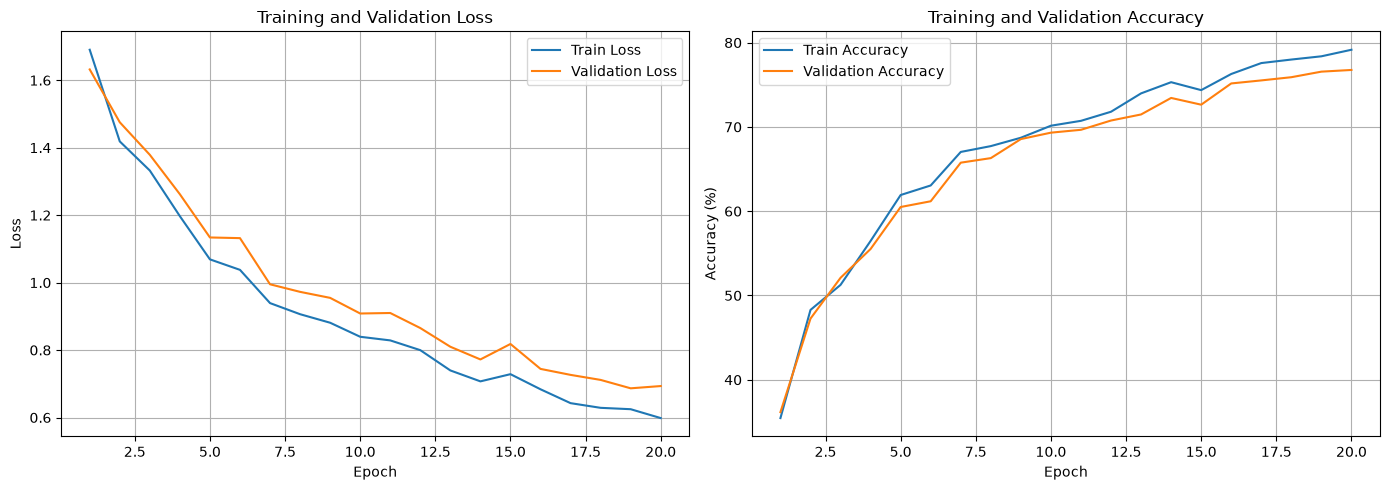

In [40]:
print(f"\n========== 开始 InceptionNetCIFAR10 训练 (epochs={epochs}) ==========")
# 创建 Trainer 实例，封装完整训练流程
trainer = Trainer(
    model=model,  # 待训练的 InceptionNetCIFAR10 模型
    trainloader=train_loader,  # 训练集 DataLoader（含数据增强）
    valloader=val_loader,  # 验证集 DataLoader（仅归一化）
    criterion=criterion,  # 损失函数（交叉熵）
    optimizer=optimizer,  # 优化器（Adam, lr=0.001）
    device=device,  # 训练设备（GPU 或 CPU）
    epochs=epochs,  # 最大训练轮数 20
    early_stopping=True,  # 启用早停: 验证准确率不再提升时自动停止
    patience=5,  # 早停容忍度: 连续 5 轮验证准确率未提升则停止训练
    save_path="best_model_inception_cifar10.pth",  # InceptionNet 最优权重保存路径
    early_stop_mode="acc",  # 早停依据: 以验证集准确率为监控指标
    maximize_acc=True,  # 准确率越大越好（标准分类任务）
    use_tensorboard=False  # 不使用 TensorBoard（若需要可视化日志可设为 True + 改 log_dir）
)

trainer.train()  # 开始训练: 包含前向、反向、评估、早停、保存最优模型等完整流程
trainer.plot(acc=True)  # 绘制训练/验证损失和准确率曲线（双图并排）

## 14. 验证集评估

In [41]:
# 使用训练好的最优模型（Trainer 内部已恢复到 best_epoch 的权重）在验证集上评估
test_loss, test_acc = trainer.evaluating(val_loader)  # 调用 evaluating 获得 (平均损失, 准确率%)
print(f"\n========== InceptionNetCIFAR10 验证集评估结果 ==========")  # 分隔标题
print(f"InceptionNetCIFAR10 - Val Loss: {test_loss:.4f}, Val Accuracy: {test_acc:.2f}%")  # 打印验证结果


========== InceptionNetCIFAR10 验证集评估结果 ==========
InceptionNetCIFAR10 - Val Loss: 0.6933, Val Accuracy: 76.76%


## 15. InceptionNet 模型总结与分析

### 模型关键指标

In [42]:
print(f"\n模型名称: InceptionNetCIFAR10")  # 模型名称
print(f"总参数量: {total_params_all:,}")  # 约 318,498
print(f"可训练参数量: {total_params:,}")  # 约 318,498（全部可训练）
print(f"输入尺寸: (3, 32, 32)")  # CIFAR-10 标准输入尺寸
print(f"输出类别数: 10")  # CIFAR-10 的 10 个类别
print(f"验证集准确率: {test_acc:.2f}%")  # 训练后在验证集上的准确率


模型名称: InceptionNetCIFAR10
总参数量: 318,498
可训练参数量: 318,498
输入尺寸: (3, 32, 32)
输出类别数: 10
验证集准确率: 76.76%


### 模型架构分析

In [43]:
print(f"\n架构特点:")  # 架构特点标题
print(f"  1. Inception 多分支结构:")  # 核心设计
print(f"     - 每个 InceptionBlock 包含 4 个并行分支（1×1, 3×3, 5×5, maxpool）")  # 分支说明
print(f"     - 不同分支提取不同感受野的特征，然后将结果沿通道拼接")  # 拼接方式
print(f"     - 1×1 卷积用作瓶颈层（bottleneck），先降维再卷积，大幅减少计算量")  # 瓶颈层作用
print(f"  2. 模型轻量化:")  # 效率分析
print(f"     - 总参数仅约 318K，远小于 VGG11（~9.3M）和 ResNet18（~11.2M）")  # 参数量对比
print(f"     - 适合快速实验、小数据集、低计算资源场景")  # 适用场景
print(f"     - 可在 CPU 上快速训练（几分钟～十几分钟）")  # CPU 训练时间
print(f"  3. 全局平均池化:")  # 池化策略
print(f"     - 使用 AdaptiveAvgPool2d 替代大量全连接层")  # 替代方案
print(f"     - 减少参数量的同时具有一定的正则化效果（减轻过拟合）")  # 正则化
print(f"  4. 批归一化 (BatchNorm):")  # BN 作用
print(f"     - 在初始卷积后使用 BN，加速收敛，稳定训练")  # 加速收敛
print(f"     - 配合 ReLU 激活，缓解内部协变量偏移问题")  # 内部协变量偏移


架构特点:
  1. Inception 多分支结构:
     - 每个 InceptionBlock 包含 4 个并行分支（1×1, 3×3, 5×5, maxpool）
     - 不同分支提取不同感受野的特征，然后将结果沿通道拼接
     - 1×1 卷积用作瓶颈层（bottleneck），先降维再卷积，大幅减少计算量
  2. 模型轻量化:
     - 总参数仅约 318K，远小于 VGG11（~9.3M）和 ResNet18（~11.2M）
     - 适合快速实验、小数据集、低计算资源场景
     - 可在 CPU 上快速训练（几分钟～十几分钟）
  3. 全局平均池化:
     - 使用 AdaptiveAvgPool2d 替代大量全连接层
     - 减少参数量的同时具有一定的正则化效果（减轻过拟合）
  4. 批归一化 (BatchNorm):
     - 在初始卷积后使用 BN，加速收敛，稳定训练
     - 配合 ReLU 激活，缓解内部协变量偏移问题


### 与其它模型的对比

In [44]:
print(f"\n与其他模型对比:")  # 对比标题
print(f"  模型            总参数量      特点")
print(f"  ───────────────────────────────────────────────")
print(f"  InceptionNet    ~318K        多分支并行，轻量高效")
print(f"  VGG11           ~9.3M        纯串联，结构简单")
print(f"  ResNet18        ~11.2M       残差连接，深层可训练")
print(f"  SimpleConvNet   ~4.5M        三组 Conv×2+Pool，入门级 CNN")


与其他模型对比:
  模型            总参数量      特点
  ───────────────────────────────────────────────
  InceptionNet    ~318K        多分支并行，轻量高效
  VGG11           ~9.3M        纯串联，结构简单
  ResNet18        ~11.2M       残差连接，深层可训练
  SimpleConvNet   ~4.5M        三组 Conv×2+Pool，入门级 CNN


### 改进建议

In [45]:
print(f"\n改进方向:")  # 改进标题
print(f"  - 增加 InceptionBlock 数量或调整各分支通道数以提升模型容量")
print(f"  - 在 InceptionBlock 中添加 BatchNorm 层以进一步稳定训练")
print(f"  - 使用学习率调度器（如 CosineAnnealingLR）动态调整学习率")
print(f"  - 结合更强的数据增强策略（Cutout、Mixup、AutoAugment）")
print(f"  - 使用 Label Smoothing 交叉熵损失缓解过拟合")


改进方向:
  - 增加 InceptionBlock 数量或调整各分支通道数以提升模型容量
  - 在 InceptionBlock 中添加 BatchNorm 层以进一步稳定训练
  - 使用学习率调度器（如 CosineAnnealingLR）动态调整学习率
  - 结合更强的数据增强策略（Cutout、Mixup、AutoAugment）
  - 使用 Label Smoothing 交叉熵损失缓解过拟合
